<a href="https://colab.research.google.com/github/kamxsato/MIS444_Final_Project/blob/main/24104087_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 0. Libraries

In [1]:
# 0.1 import libraries
import pandas as pd
import numpy as np
from google.colab import drive
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# 1. Load Data

In [2]:
# 1.1 load dataset
train = pd.read_csv('/content/drive/MyDrive/死/Summer 2026/MIS444/Project/train.csv')
test = pd.read_csv('/content/drive/MyDrive/死/Summer 2026/MIS444/Project/test.csv')

print(f"✅ Dataset loaded. Shape: {train.shape}")
print('=== train data ===')
display(train.head(3))
display(train.tail(3))

print(f"✅ Dataset loaded. Shape: {test.shape}")
print('=== test data ===')
display(test.head(3))
display(test.tail(3))

✅ Dataset loaded. Shape: (691369, 14)
=== train data ===


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1
691368,691368,21.0,5.64,1.03,3.05,1.01,4.91,169.0,NaN,9.47,Other,Medium,Yes,0


✅ Dataset loaded. Shape: (296302, 13)
=== test data ===


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
296299,987668,33.0,5.27,1.84,0.20,2.44,8.29,96.0,73.0,6.57,Female,High,No
296300,987669,NaN,NaN,1.25,0.52,0.71,6.27,57.0,38.0,7.19,Female,Low,Yes
296301,987670,30.0,6.68,2.20,2.13,1.51,NaN,162.0,117.0,7.78,Male,NaN,Yes


In [3]:
# 1.1 inspect data

overview_train = pd.DataFrame({
    'dtype': train.dtypes,
    'nunique': train.nunique(),
    'nulls': train.isnull().sum(),
    'null_%': (train.isnull().mean()*100).round(2),
    'sample': [train[c].dropna().iloc[0] if train[c].notna().any() else 'ALL NULL' for c in train.columns]
})

overview_test = pd.DataFrame({
    'dtype': test.dtypes,
    'nunique': test.nunique(),
    'nulls': test.isnull().sum(),
    'null_%': (test.isnull().mean()*100).round(2),
    'sample': [test[c].dropna().iloc[0] if test[c].notna().any() else 'ALL NULL' for c in test.columns]
})

print('=== train data overview ===')
display(overview_train)
print('=== test data overview===')
display(overview_test)

=== train data overview ===


,dtype,nunique,nulls,null_%,sample
id,int64,691369,0,0.00,0
age,float64,18,28929,4.18,24.0
daily_screen_time_hours,float64,1389,95854,13.86,5.97
social_media_hours,float64,721,133995,19.38,1.83
gaming_hours,float64,401,126821,18.34,1.59
work_study_hours,float64,600,51518,7.45,2.11
sleep_hours,float64,451,44480,6.43,7.46
notifications_per_day,float64,231,67584,9.78,122.0
app_opens_per_day,float64,166,80710,11.67,38.0
weekend_screen_time,float64,1437,112063,16.21,8.63


=== test data overview===


,dtype,nunique,nulls,null_%,sample
id,int64,296302,0,0.00,691369
age,float64,18,17138,5.78,30.0
daily_screen_time_hours,float64,1349,32788,11.07,9.34
social_media_hours,float64,703,47397,16.00,1.91
gaming_hours,float64,401,59420,20.05,0.77
work_study_hours,float64,601,27777,9.37,4.09
sleep_hours,float64,451,22455,7.58,7.15
notifications_per_day,float64,231,34221,11.55,153.0
app_opens_per_day,float64,166,25705,8.68,16.0
weekend_screen_time,float64,1404,50697,17.11,10.68


In [4]:
display(train.describe(include='all').T)
display(test.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,691369.0,NaN,NaN,NaN,345684.0,199581.183466,0.0,172842.0,345684.0,518526.0,691368.0
age,662440.0,NaN,NaN,NaN,26.615408,5.153162,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,595515.0,NaN,NaN,NaN,7.640865,2.721446,0.5,5.48,7.77,9.84,15.0
social_media_hours,557374.0,NaN,NaN,NaN,2.471038,1.316137,0.0,1.45,2.31,3.37,8.0
gaming_hours,564548.0,NaN,NaN,NaN,1.459265,0.934552,0.0,0.7,1.33,2.09,4.0
work_study_hours,639851.0,NaN,NaN,NaN,2.366971,1.258797,0.0,1.36,2.2,3.2,6.0
sleep_hours,646889.0,NaN,NaN,NaN,6.804334,1.234512,4.5,5.78,6.8,7.87,9.0
notifications_per_day,623785.0,NaN,NaN,NaN,145.8949,65.917556,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,610659.0,NaN,NaN,NaN,102.636781,48.09397,15.0,64.0,104.0,145.0,180.0
weekend_screen_time,579306.0,NaN,NaN,NaN,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,296302.0,NaN,NaN,NaN,839519.5,85535.164068,691369.0,765444.25,839519.5,913594.75,987670.0
age,279164.0,NaN,NaN,NaN,26.608689,5.153359,18.0,22.0,27.0,31.0,35.0
daily_screen_time_hours,263514.0,NaN,NaN,NaN,7.640771,2.725921,0.5,5.46,7.77,9.85,15.0
social_media_hours,248905.0,NaN,NaN,NaN,2.471224,1.318143,0.0,1.45,2.32,3.37,7.85
gaming_hours,236882.0,NaN,NaN,NaN,1.457668,0.934727,0.0,0.69,1.33,2.09,4.0
work_study_hours,268525.0,NaN,NaN,NaN,2.365962,1.257023,0.0,1.36,2.2,3.2,6.0
sleep_hours,273847.0,NaN,NaN,NaN,6.801704,1.23608,4.5,5.77,6.8,7.87,9.0
notifications_per_day,262081.0,NaN,NaN,NaN,145.748066,66.014554,20.0,93.0,150.0,204.0,250.0
app_opens_per_day,270597.0,NaN,NaN,NaN,102.656216,48.1862,15.0,63.0,104.0,145.0,180.0
weekend_screen_time,245605.0,NaN,NaN,NaN,9.474575,2.858384,0.51,7.27,9.58,11.75,17.56


# 2. Preprocessing

In [5]:
# 2.1 missing values detection

missing_train = pd.DataFrame({
    'Data Type': train.dtypes,
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_train[missing_train['Missing Count'] > 0]

missing_test = pd.DataFrame({
    'Data Type': test.dtypes,
    'Missing Count': test.isnull().sum(),
    'Missing %': (test.isnull().sum() / len(test) * 100).round(2)
}).sort_values('Missing %', ascending=False)
missing_test[missing_test['Missing Count'] > 0]

print('=== train data missing value ===')
display(missing_train)
print('=== test data missing value ===')
display(missing_test)

=== train data missing value ===


,Data Type,Missing Count,Missing %
social_media_hours,float64,133995,19.38
gaming_hours,float64,126821,18.34
weekend_screen_time,float64,112063,16.21
daily_screen_time_hours,float64,95854,13.86
app_opens_per_day,float64,80710,11.67
notifications_per_day,float64,67584,9.78
stress_level,object,55148,7.98
work_study_hours,float64,51518,7.45
sleep_hours,float64,44480,6.43
academic_work_impact,object,44224,6.40


=== test data missing value ===


,Data Type,Missing Count,Missing %
gaming_hours,float64,59420,20.05
weekend_screen_time,float64,50697,17.11
social_media_hours,float64,47397,16.00
notifications_per_day,float64,34221,11.55
daily_screen_time_hours,float64,32788,11.07
work_study_hours,float64,27777,9.37
app_opens_per_day,float64,25705,8.68
academic_work_impact,object,25721,8.68
sleep_hours,float64,22455,7.58
stress_level,object,19626,6.62


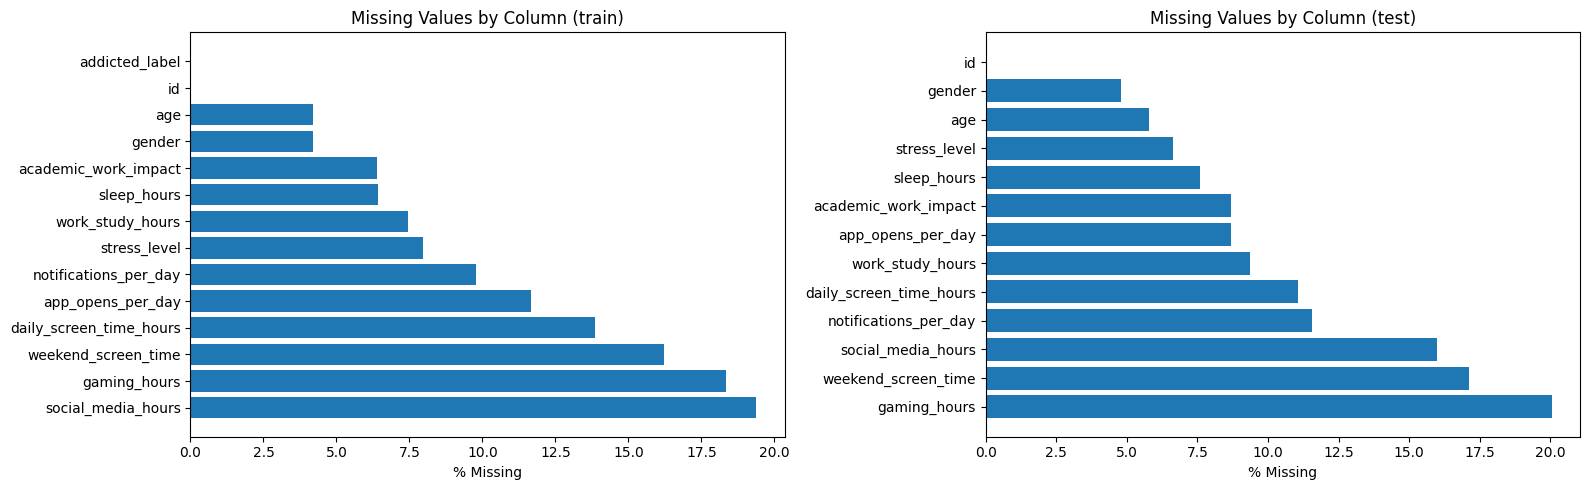

In [6]:
# 2.2 missing data visualisation

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].barh(missing_train.index, missing_train['Missing %'])
axes[0].set_xlabel('% Missing')
axes[0].set_title('Missing Values by Column (train)')

axes[1].barh(missing_test.index, missing_test['Missing %'])
axes[1].set_xlabel('% Missing')
axes[1].set_title('Missing Values by Column (test)')
plt.tight_layout()
plt.show()

In [7]:
train.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [8]:
# 2.3 missing value treatment
# 2.3.1 Numeric data with less than 10% missing data
age_median_train = train['age'].median()
age_median_test = test['age'].median()
train['age'] = train['age'].fillna(age_median_train)
test['age'] = test['age'].fillna(age_median_test)

print(f'Age median fill(train): {age_median_train}')
print(f'Age median fill(test): {age_median_test}')

Age median fill(train): 27.0
Age median fill(test): 27.0


In [9]:
sleep_hours_median_train = train['sleep_hours'].median()
sleep_hours_median_test = test['sleep_hours'].median()
train['sleep_hours'] = train['sleep_hours'].fillna(sleep_hours_median_train)
test['sleep_hours'] = test['sleep_hours'].fillna(sleep_hours_median_test)

print(f'sleep_hours median fill(train): {sleep_hours_median_train}')
print(f'sleep_hours median fill(test): {sleep_hours_median_test}')

sleep_hours median fill(train): 6.8
sleep_hours median fill(test): 6.8


In [10]:
work_study_hours_median_train = train['work_study_hours'].median()
work_study_hours_median_test = test['work_study_hours'].median()
train['work_study_hours'] = train['work_study_hours'].fillna(work_study_hours_median_train)
test['work_study_hours'] = test['work_study_hours'].fillna(work_study_hours_median_test)

print(f'work_study_hours median fill(train): {work_study_hours_median_train}')
print(f'work_study_hours median fill(test): {work_study_hours_median_test}')

work_study_hours median fill(train): 2.2
work_study_hours median fill(test): 2.2


In [11]:
notifications_per_day_median_train = train['notifications_per_day'].median()
train['notifications_per_day'] = train['notifications_per_day'].fillna(notifications_per_day_median_train)

print(f'notifications_per_day median fill(train): {notifications_per_day_median_train}')

notifications_per_day median fill(train): 150.0


In [13]:
app_opens_per_day_median_test = test['app_opens_per_day'].median()
test['app_opens_per_day'] = test['app_opens_per_day'].fillna(app_opens_per_day_median_test)

print(f'app_opens_per_day median fill(test): {app_opens_per_day_median_test}')

app_opens_per_day median fill(test): 104.0


In [12]:
# 2.3.2 KNN imputation for missing value greater than 10%
test['notifications_per_day'] = KNNImputer(n_neighbors= 3, weights= "distance").fit_transform(test[['notifications_per_day']])